# Assignment: Exploratory Data Analysis (EDA)
### Dataset: Chocolate Sales

In this assignment, we perform a comprehensive EDA on the chocolate sales dataset to identify trends, top performers, and relationships between variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

## 1. Data Loading and Cleaning
We load the dataset and perform necessary type conversions for dates and currency.

In [2]:
# Load data
df = pd.read_csv('Chocolate_Sales.csv')

# Clean 'Amount' column (removing $ and ,)
df['Amount'] = df['Amount'].replace('[\$,]', '', regex=True).astype(float)

# Convert 'Date' to datetime objects
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.head()

<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/var/folders/3s/j41d0_ns30gbq423nh9d_flh0000gn/T/ipykernel_51498/349258620.py:5: SyntaxWarning: invalid escape sequence '\$'
  df['Amount'] = df['Amount'].replace('[\$,]', '', regex=True).astype(float)


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.0,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.0,184


## 2. Basic Exploration
Checking the shape, missing values, and statistical summary.

In [3]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe())

Dataset Shape: (3282, 6)

Missing Values:
 Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

Statistical Summary:
                              Date        Amount  Boxes Shipped
count                        3282   3282.000000    3282.000000
mean   2023-05-03 15:09:06.252285   6030.338775     164.666971
min           2022-01-03 00:00:00      7.000000       1.000000
25%           2022-07-04 00:00:00   2521.495000      71.000000
50%           2023-05-11 00:00:00   5225.500000     137.000000
75%           2024-03-02 00:00:00   8556.842500     232.000000
max           2024-08-31 00:00:00  26170.950000     778.000000
std                           NaN   4393.980200     124.024736


## 3. Univariate Analysis
### Distribution of Boxes Shipped

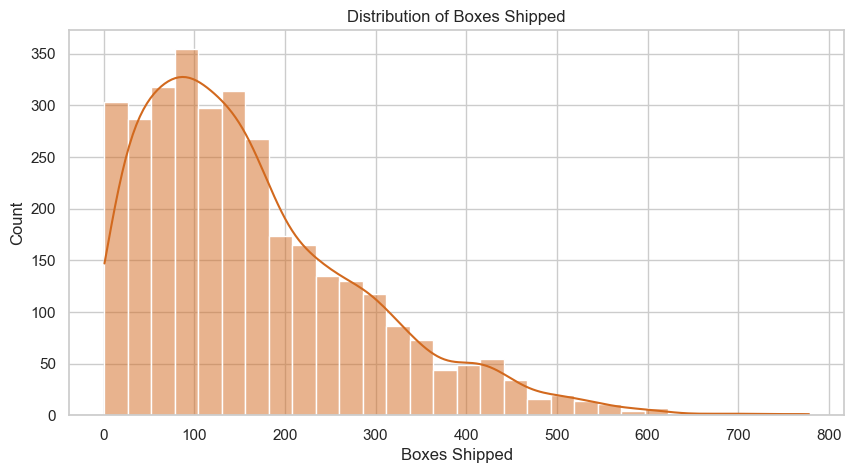

In [4]:
plt.figure(figsize=(10,5))
sns.histplot(df['Boxes Shipped'], bins=30, kde=True, color='chocolate')
plt.title("Distribution of Boxes Shipped")
plt.show()

### Distribution of Revenue (Amount)

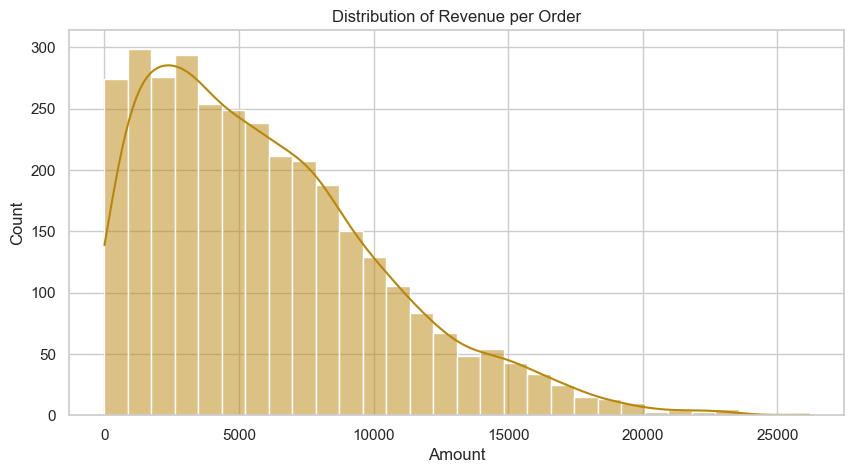

In [5]:
plt.figure(figsize=(10,5))
sns.histplot(df['Amount'], bins=30, kde=True, color='darkgoldenrod')
plt.title("Distribution of Revenue per Order")
plt.show()

## 4. Bivariate Analysis
### Total Revenue by Country

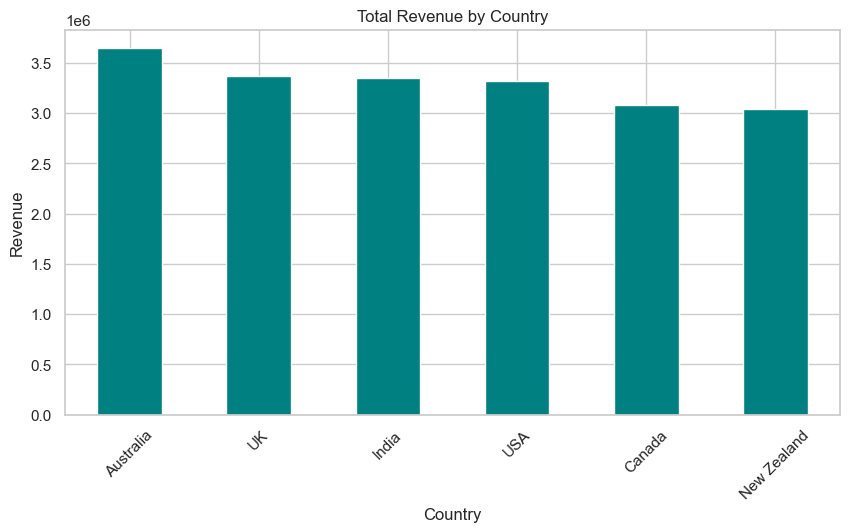

In [6]:
country_revenue = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
country_revenue.plot(kind='bar', color='teal')
plt.title("Total Revenue by Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### Top 10 Products by Revenue

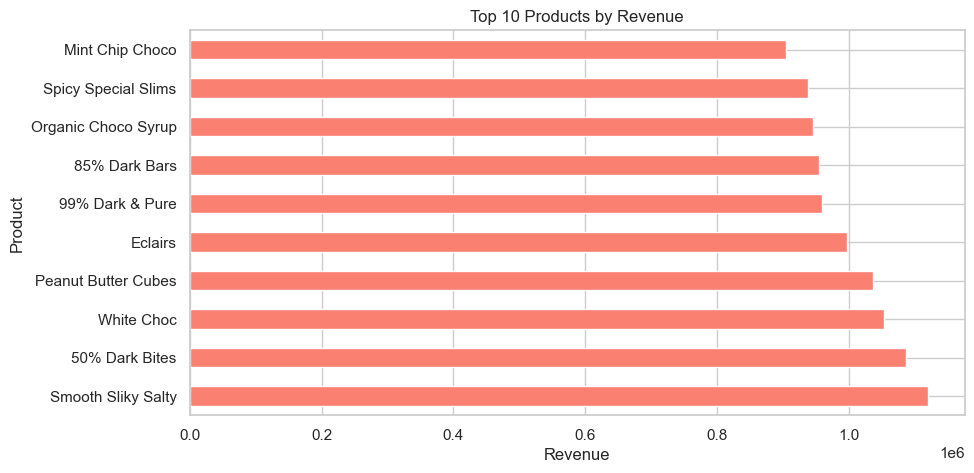

In [7]:
product_revenue = df.groupby('Product')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
product_revenue.plot(kind='barh', color='salmon')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.show()

### Boxes Shipped vs Revenue Relationship

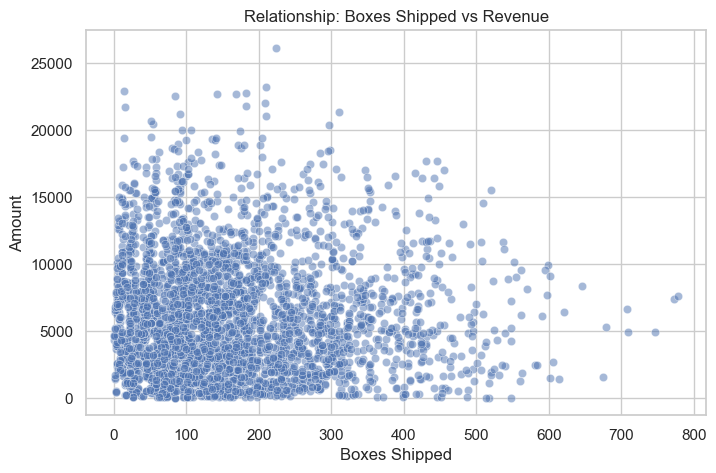

Correlation Matrix:
               Boxes Shipped    Amount
Boxes Shipped       1.000000 -0.013154
Amount             -0.013154  1.000000


In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Boxes Shipped', y='Amount', data=df, alpha=0.5)
plt.title("Relationship: Boxes Shipped vs Revenue")
plt.show()

print("Correlation Matrix:")
print(df[['Boxes Shipped', 'Amount']].corr())

## 5. Time-Based Analysis
### Monthly Revenue Trend

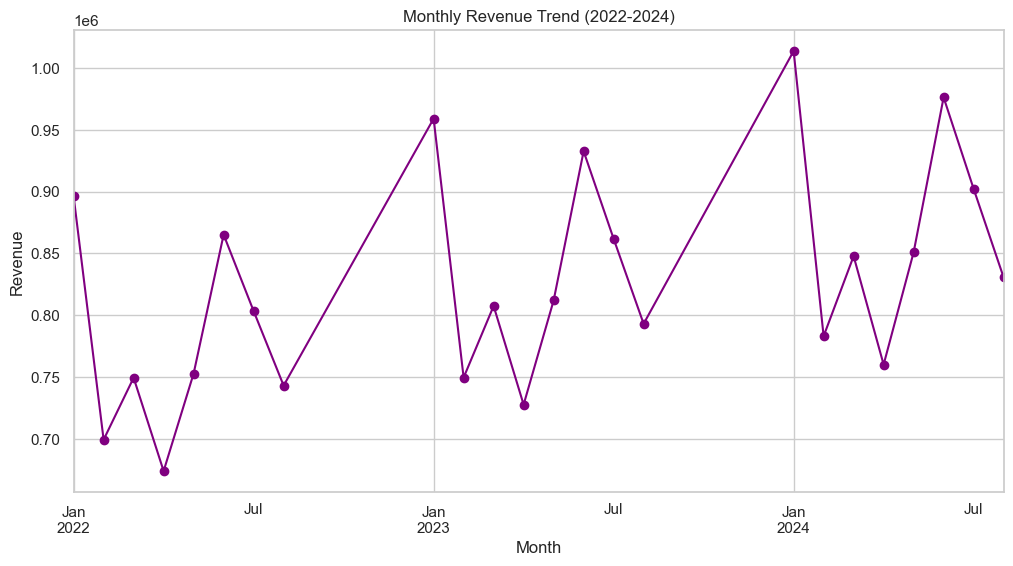

In [9]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Amount'].sum()

plt.figure(figsize=(12,6))
monthly_revenue.plot(marker='o', linestyle='-', color='purple')
plt.title("Monthly Revenue Trend (2022-2024)")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()